In [112]:
import sys
sys.path.append('../')
from source import Node 
from source import Align
import glob
from pathlib import Path
import networkx as nx
from ipysigma import Sigma
import pandas as pd
import math
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [113]:
# Node.PrepareGenomeQueryFasta(
#     genomes_dir="../data/genomes"
# )

In [114]:
FastaFiles = glob.glob("../data/processed/selected_components/*.fasta")
FastaFiles

['../data/processed/selected_components/ProblematicComponentsByClass.aminocoumarin.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.aminoglycoside.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.bacitracin.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.beta-lactam.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.colistin.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.drug_and_biocide_and_metal_resistance.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.drug_and_biocide_resistance.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.elfamycin.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.fluoroquinolone.fasta',
 '../data/processed/selected_components/ProblematicComponentsByClass.fosfomycin.fasta',
 '../data/processed/selected_components/ProblematicComponentsByCla

In [115]:
for file in FastaFiles:
    name = file.split("/")[-1].split(".")[-2]
    if not Path(f"../data/processed/diamond_db/{name}.dmnd").is_file():
        Node.MakeDiamondDB(
        fasta_dir=file,
        db_dir="../data/processed/diamond_db/",
        db_name = name)
    print("All databases are already created")

All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created
All databases are already created


In [116]:
DiamondDatabase = glob.glob("../data/processed/diamond_db/*.dmnd")
DiamondDatabase

['../data/processed/diamond_db/aminocoumarin.dmnd',
 '../data/processed/diamond_db/aminoglycoside.dmnd',
 '../data/processed/diamond_db/bacitracin.dmnd',
 '../data/processed/diamond_db/beta-lactam.dmnd',
 '../data/processed/diamond_db/colistin.dmnd',
 '../data/processed/diamond_db/drug_and_biocide_and_metal_resistance.dmnd',
 '../data/processed/diamond_db/drug_and_biocide_resistance.dmnd',
 '../data/processed/diamond_db/elfamycin.dmnd',
 '../data/processed/diamond_db/fluoroquinolone.dmnd',
 '../data/processed/diamond_db/fosfomycin.dmnd',
 '../data/processed/diamond_db/fosmidomycin.dmnd',
 '../data/processed/diamond_db/glycopeptide.dmnd',
 '../data/processed/diamond_db/macrolide.dmnd',
 '../data/processed/diamond_db/multidrug.dmnd',
 '../data/processed/diamond_db/phosphonic_acid.dmnd',
 '../data/processed/diamond_db/polymyxin.dmnd',
 '../data/processed/diamond_db/quinolone.dmnd',
 '../data/processed/diamond_db/rifampin.dmnd',
 '../data/processed/diamond_db/tetracycline.dmnd']

In [117]:
for database in DiamondDatabase:
    name = database.split("/")[-1].split(".")[0]
    name = name.replace(" ","_")
    if not Path(f"../data/processed/diamond_results/NodeProteinAlignment.{name}.tsv").is_file():
        Align.RunDiamond(
            query="../data/genomes/all_genomes_query.fasta",
            db=database,
            output=f"../data/processed/diamond_results/NodeProteinAlignment.{name}.tsv",
            maxseq=6,
            qcov = 80,
            minid = 90
            )
    else:
        print("All alignments done!")

All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!
All alignments done!


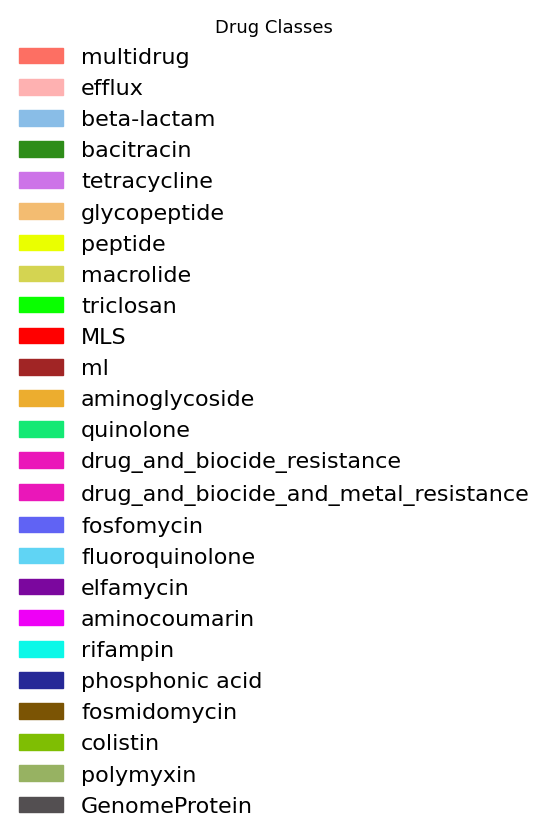

In [118]:
color_map = {
    'multidrug':      "#FD6F63",
    'efflux':         "#FEB1B1",     
    'beta-lactam':    "#89BDE7",  
    'bacitracin':     "#2E8D19",    
    'tetracycline':   "#CD73E8",
    'glycopeptide':   "#F3BC71",  
    'peptide':        "#EAFF00",  
    'macrolide':      "#D4D451",
    'triclosan':      "#09FF00",
    'MLS':            "#FF0000",
    'ml':              "#A12525",
    'aminoglycoside': "#ECAD2F", 
    'quinolone':      "#14E974",
    'drug_and_biocide_resistance': "#EA17B9",
    "drug_and_biocide_and_metal_resistance": "#EA17B9",
    'fosfomycin':     "#6063F4",
    'fluoroquinolone':"#60D4F4",
    'elfamycin':      "#7B079E",
    'aminocoumarin':  "#EE00F6",
    'rifampin':       "#0BF8E8",
    'phosphonic acid':"#262897",
    'fosmidomycin':   "#7B5404",
    'colistin' :      "#7FBE03",
    'polymyxin':      "#97B262",
    'GenomeProtein':"#534F51",
    }

import matplotlib.patches as mpatches
legend_elements = [
    mpatches.Patch(color=color, label=label) 
    for label, color in color_map.items()
]

# Configurando uma figura vazia apenas para conter a legenda
fig, ax = plt.subplots(figsize=(4, 6))
ax.axis('off') # Esconde os eixos do gráfico

# Desenhando a legenda centralizada
ax.legend(
    handles=legend_elements, 
    loc='center', 
    frameon=True, 
    facecolor='white', 
    edgecolor='none',
    fontsize=16,
    title="Drug Classes",
    title_fontsize=13
)

# Salvando a legenda de forma que as bordas extras sejam cortadas
plt.savefig("../figures/Network_Legend.svg", format="svg", bbox_inches='tight', dpi=180)
plt.show()

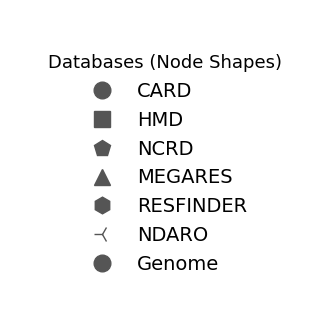

In [119]:
node_shape_map = {
    "CARD": "circle",
    "HMD": "square",
    "NCRD": "pentagon",
    "MEGARES": "triangle",
    "RESFINDER": "hexagon",
    "NDARO": "cloud",
    "Genome": "circle"
}

import matplotlib.lines as mlines

# Tradução de nomes textuais para marcadores do Matplotlib
matplotlib_markers = {
    "circle": "o", 
    "square": "s", 
    "pentagon": "p", 
    "triangle": "^", 
    "hexagon": "h", 
    "cloud": "3" # Marcador tri-radial que se assemelha a uma nuvem no Matplotlib
}

# Criando as formas geométricas usando Line2D (linhas invisíveis, apenas marcadores visíveis)
legend_elements = [
    mlines.Line2D(
        [], [], 
        color="#555555",                  # Cor padrão para os símbolos da legenda
        marker=matplotlib_markers[shape], # Pega o caractere correto do Matplotlib
        linestyle='None', 
        markersize=12, 
        label=label
    )
    for label, shape in node_shape_map.items()
]

# Configurando a figura vazia para a legenda
fig, ax = plt.subplots(figsize=(4, 4))
ax.axis('off') # Esconde eixos e bordas do gráfico

# Renderizando a legenda centralizada
ax.legend(
    handles=legend_elements, 
    loc='center', 
    frameon=True, 
    facecolor='white', 
    edgecolor='none',
    fontsize=14,
    title="Databases (Node Shapes)",
    title_fontsize=13
)

# Salvando a figura cortando espaços em branco inúteis
plt.savefig("../figures/Network_Shapes_Legend.svg", format="svg", bbox_inches='tight', dpi=180)
plt.show()

In [120]:
TargetClass = "bacitracin"
ProblematicComponentsByClass = nx.read_graphml(f"../data/processed/ProblematicComponentsByClass.{TargetClass}.graphml")
for nodes in ProblematicComponentsByClass.nodes(data=True):
    Database = nodes[0].split("_")[0].strip()
    nodes[1]['Database'] = Database

In [121]:
GenomeNodesAligned = pd.read_csv(
    f"../data/processed/diamond_results/NodeProteinAlignment.{TargetClass}.tsv", 
    sep = "\t",
    skipinitialspace=True, 
    header=None,
    names = "qseqid sseqid stitle pident length qlen slen qstart qend sstart send evalue bitscore ppos full_qseq full_sseq".split(" ")
)
GenomeNodesAligned["sseqid"] = GenomeNodesAligned.sseqid.apply(lambda x: x.split("|")[0])

In [122]:
ProblematicComponentsByClass_AndGenomes = nx.Graph(ProblematicComponentsByClass)
GenomeNodesDict = {}
NewNodes = []
for _,i in GenomeNodesAligned.iterrows():
    ProblematicComponentsByClass_AndGenomes.add_edge(i["sseqid"],i["qseqid"], pident = i["pident"])
    GenomeNodesDict[i["qseqid"]] = {"Drug Class":"GenomeProtein", "Sequence":i["full_qseq"], "Name":i["qseqid"].split("|")[-1], "Database":"Genome"}
nx.set_node_attributes(ProblematicComponentsByClass_AndGenomes, GenomeNodesDict)

In [123]:
meu_layout = {
    "scalingRatio": 50.0,           # Aumente para afastar os grupos
    "gravity": 0.7,                 # Reduza para não amontoar no centro
    "repulsion": 5,               # Aumente para afastar os nós
    # "outboundAttractionDistribution": True, # Empurra hubs para fora
    # "barnesHutOptimize": True,      # Essencial para seus 70k nós
    # "linLogMode": True              # Melhora a definição de clusters biológicos 
}
Sigma(
    ProblematicComponentsByClass_AndGenomes,
    node_shape = "Database",
    node_shape_mapping = node_shape_map,
    node_size  = ProblematicComponentsByClass_AndGenomes.degree(),
    node_color =  [ProblematicComponentsByClass_AndGenomes.nodes[n].get("Drug Class") for n in ProblematicComponentsByClass_AndGenomes.nodes()],
    raw_node_color=True,
    node_color_palette = color_map,
    default_edge_type = "curve",
    layout_settings=meu_layout,
    start_layout=40,
    label_density = 0
    )

Sigma(nx.Graph with 3,085 nodes and 2,663 edges)

In [124]:
NodeBait = "HMD_6732"
NodeNames = []
GenomeProteins = []
StringFasta = []
for component in list(nx.connected_components(ProblematicComponentsByClass_AndGenomes)):
    if NodeBait.strip() in component:
        for nodes in component:
            DrugClass = ProblematicComponentsByClass_AndGenomes.nodes[nodes]['Drug Class']
            Sequence = ProblematicComponentsByClass_AndGenomes.nodes[nodes]['Sequence']
            Name = ProblematicComponentsByClass_AndGenomes.nodes[nodes]['Name']
            StringFasta.append(f">{nodes}|{DrugClass}|{Name}\n{Sequence}")
            if DrugClass != "GenomeProtein":
                NodeNames.append(Name)
            else:
                GenomeProteins.append(Name)
AlignedComponent = Align.ProteinAligner(StringFasta)


AlignLenDist = []
with open(f"../data/processed/msa/{TargetClass}-{NodeBait}.fasta", "w+") as MSA_FILE:
    for AlignedSeq in AlignedComponent:
        MSA_FILE.write(f">{AlignedSeq.id}\n{AlignedSeq.seq}\n")
        AlignLenDist.append(len(AlignedSeq.seq.replace("-","")))
        print(f">{AlignedSeq.id}")
        print(AlignedSeq.seq)

>GCA_031378305.2|EMN5847154.1|GenomeProtein|EMN5847154.1
MSDMHSLLVAAILGVVEGLTEFLPVSSTGHMIIVGHLLGFEGDTAKTFEVVIQLGSILAVVVMFWRRLFGLIGIHFGRLPQREGEGKGRLTLIHILLGMIPAVVLGLVFHDTIKSLFNPINVMYALVVGGFLLIAAEVLKPKTPRAEGLDDMTYRQAFMIGCFQCLALWPGFSRSGATISGGMLMGVSRYAASEFSFLLAVPMMMGATALDLYKSIGFLTVGDIPMFAVGFITAFIVALIAIKTFLQLIKRISFIPFAIYRFIVAAAVYVVFF
>GCA_031378665.2|EMP2221483.1|GenomeProtein|EMP2221483.1
MSDMHSLLVAAILGVVEGLTEFLPVSSTGHMIIVGHLLGFEGDTAKTFEVVIQLGSILAVVVMFWRRLFGLIGIHFGRLPQREGEGKGRLTLIHILLGMIPAVVLGLVFHDTIKSLFNPINVMYALVVGGFLLIAAEVLKPKTPRAEGLDDMTYRQAFMIGCFQCLALWPGFSRSGATISGGMLMGVSRYAASEFSFLLAVPMMMGATALDLYKSIGFLTVGDIPMFAVGFITAFIVALIAIKTFLQLIKRISFIPFAIYRFIVAAAVYVVFF
>NCRD_4301|glycopeptide|baca
MSDMHSLLVAAILGVVEGLTEFLPVSSTGHMIIVGHLLGFEGDTAKTFEVVIQLGSILAVVVMFWRRLFGLIGIHFGRPPQHEGAGKGRLSLIHILLGMIPAVVLGLVFHDAIKSLFNPINVMYALVVGGFLLIAAEVLKPKTPRAEGVDDMTYRQAFIIGCFQCLALWPGFSRSGATISGGMLMGVSRYAASEFSFLLAVPMMMGATVLDVYKSYHFLTAGDIPMFAVGFITAFIVALIAIKTFLQLIKRISFIPFAIYRFIVAAAVYVVFF
>HMD_6732|bacitracin|uppp
MSDMHSLLV

In [125]:
len(GenomeProteins), len(NodeNames)

(18, 8)

/tmp/ipykernel_2840931/881461299.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), weight='bold')


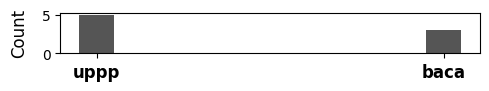

In [126]:
fig, ax = plt.subplots(figsize=(5,1))
ax.bar(
    pd.Series(NodeNames).value_counts().index,
    pd.Series(NodeNames).value_counts().values,
    width = 0.1,
    color = '#555555'
)
ax.set_ylabel("Count",fontsize = 12, labelpad=10)
ax.tick_params(axis='x', labelsize=12)
ax.set_xticklabels(ax.get_xticklabels(), weight='bold')
plt.tight_layout() 
plt.savefig(f"../figures/NodeNames.{TargetClass}.{NodeBait}.svg", 
            format="svg", 
            dpi=180, 
            bbox_inches='tight')

In [127]:
def ShannonEntropy(Column, IgnorGap = True):
    if IgnorGap:
        Column = [residue for residue in Column if residue != "-"]
    TotalResidues = len(Column)
    if TotalResidues == 0:
        return 0
    Count = Counter(Column)
    Entropy = 0
    for value in Count.values():
        p = value/TotalResidues
        Entropy -= p*math.log2(p)
    return Entropy

In [128]:
AlignLen = AlignedComponent.get_alignment_length()
EntropyForPosition = []

In [129]:
for i in range(0,AlignLen):
    Col = AlignedComponent[:,i]
    h  =  ShannonEntropy(Col, IgnorGap=False)
    EntropyForPosition.append({
        "Position": i+1,
        "Entropy":round(h,3)
    })
EntropyFrame = pd.DataFrame(EntropyForPosition)

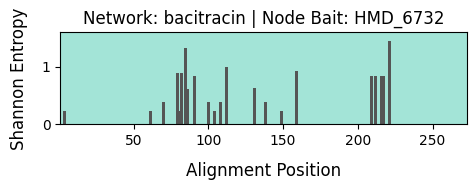

In [130]:
fig, ax = plt.subplots(figsize=(5,2))
ax.set_facecolor('#A3E4D7')
ax.bar(
    EntropyFrame['Position'],
    EntropyFrame['Entropy'],
    width = 2,
    color = '#555555'
)
ax.set_xlim(EntropyFrame["Position"].min(), EntropyFrame["Position"].max())
ax.set_ylim(0, EntropyFrame["Entropy"].max() * 1.1)
ax.set_xlabel("Alignment Position", fontsize = 12, labelpad=10)
ax.set_ylabel("Shannon Entropy",fontsize = 12, labelpad=10)
ax.set_title(f"Network: {TargetClass} | Node Bait: {NodeBait}")

plt.tight_layout() 
plt.savefig(f"../figures/ShannonEntropy.{TargetClass}.{NodeBait}.svg", 
            format="svg", 
            dpi=180, 
            bbox_inches='tight')

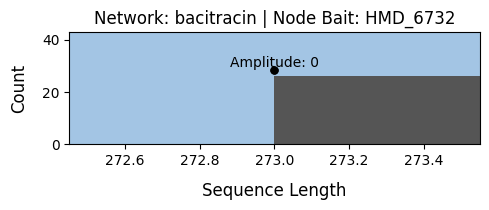

In [131]:
val_min = min(AlignLenDist)
val_max = max(AlignLenDist)

fig, ax = plt.subplots(figsize=(5,2.2))
ax.set_facecolor("#A3C5E4")

counts, bins, patches = ax.hist(
    AlignLenDist,
    width = 3,
    color = "#555555"
)

altura_da_linha = max(counts) * 1.1

ax.hlines(y=altura_da_linha, xmin=val_min, xmax=val_max, color='#000000', linestyle='--', linewidth=1)
ax.plot([val_min, val_max], [altura_da_linha, altura_da_linha], 'o', markersize=5, color = '#000000')
ax.set_ylim(0, altura_da_linha * 1.5)


x_center = (val_min + val_max) / 2
max_y = max(counts)
y_position = max_y * 1.15


ax.text(
    x_center,           
    altura_da_linha, 
    f"Amplitude: {val_max - val_min}",          
    color='#000000',      
    fontsize=10,          
    ha='center',           
    va='bottom'            
)

ax.set_xlabel("Sequence Length", fontsize = 12, labelpad=10)
ax.set_ylabel("Count", fontsize = 12, labelpad=10)
ax.set_title(f"Network: {TargetClass} | Node Bait: {NodeBait}")

plt.tight_layout() 
plt.savefig(f"../figures/ComponentLenDist.{TargetClass}.{NodeBait}.svg", 
            format="svg", 
            dpi=180, 
            bbox_inches='tight')

In [132]:
val_min,val_max


(273, 273)